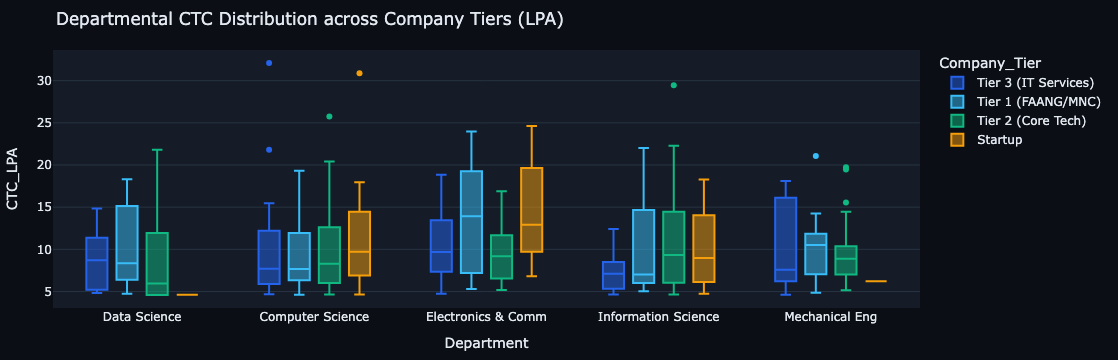

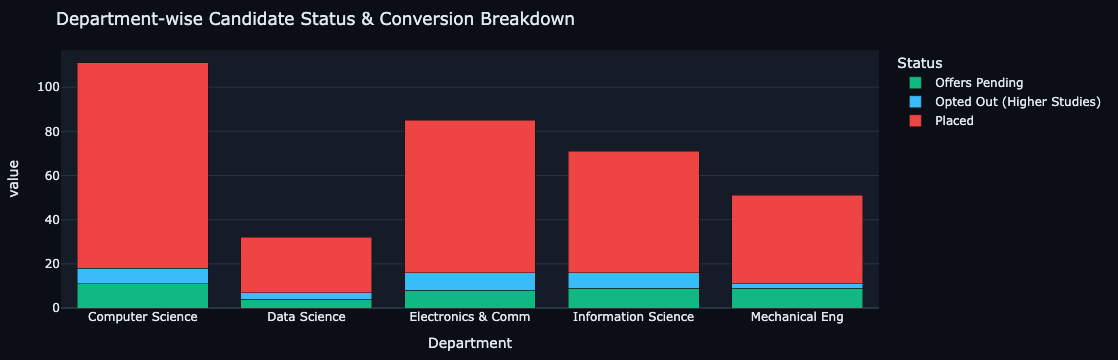

,Student_ID,Department,Company_Tier,CTC_LPA,Status,SLA_Days_To_Offer
0,USN-1BY22EC001,Electronics & Comm,Tier 2 (Core Tech),9.06,Offers Pending,24
1,USN-1BY22EC002,Data Science,Tier 3 (IT Services),4.82,Placed,32
2,USN-1BY22EC003,Information Science,Tier 3 (IT Services),6.96,Offers Pending,41
3,USN-1BY22EC004,Information Science,Tier 1 (FAANG/MNC),5.37,Placed,41
4,USN-1BY22EC005,Computer Science,Tier 1 (FAANG/MNC),4.89,Opted Out (Higher Studies),16
5,USN-1BY22EC006,Computer Science,Tier 3 (IT Services),32.11,Placed,41
6,USN-1BY22EC007,Computer Science,Tier 1 (FAANG/MNC),6.83,Placed,32
7,USN-1BY22EC008,Mechanical Eng,Tier 2 (Core Tech),14.46,Placed,19
8,USN-1BY22EC009,Information Science,Startup,6.26,Placed,10
9,USN-1BY22EC010,Information Science,Tier 2 (Core Tech),11.36,Placed,24


In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as bg
from IPython.display import display, HTML

# 1. Generate Synthetic College Placement Telemetry Data
np.random.seed(42)
departments = ["Computer Science", "Electronics & Comm", "Information Science", "Mechanical Eng", "Data Science"]
company_tiers = ["Tier 1 (FAANG/MNC)", "Tier 2 (Core Tech)", "Tier 3 (IT Services)", "Startup"]

n_records = 350
df_placement = pd.DataFrame({
    "Student_ID": [f"USN-1BY22EC{i:03d}" for i in range(1, n_records + 1)],
    "Department": np.random.choice(departments, size=n_records, p=[0.3, 0.25, 0.2, 0.15, 0.1]),
    "Company_Tier": np.random.choice(company_tiers, size=n_records, p=[0.25, 0.35, 0.3, 0.1]),
    "CTC_LPA": np.round(np.random.exponential(scale=6, size=n_records) + 4.5, 2),
    "Status": np.random.choice(["Placed", "Offers Pending", "Opted Out (Higher Studies)"], size=n_records, p=[0.82, 0.12, 0.06]),
    "SLA_Days_To_Offer": np.random.randint(5, 45, size=n_records)
})

# 2. Executive KPI Header HTML
total_students = len(df_placement)
placed_count = len(df_placement[df_placement["Status"] == "Placed"])
avg_ctc = df_placement[df_placement["Status"] == "Placed"]["CTC_LPA"].mean()
max_ctc = df_placement["CTC_LPA"].max()

kpi_html = f"""
<div style="background-color: #0B0E14; padding: 20px; border-radius: 10px; font-family: sans-serif; color: #E2E8F0; margin-bottom: 20px;">
    <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 1px solid #1E293B; padding-bottom: 12px; margin-bottom: 16px;">
        <div>
            <h2 style="color: #FFFFFF; margin: 0; font-size: 20px;">PlaceMux — College-Value Executive Portal</h2>
            <p style="color: #38BDF8; font-size: 11px; margin: 4px 0 0 0;">TASK 20 · Dry Run & Stakeholder Analytics</p>
        </div>
        <span style="background: rgba(16, 185, 129, 0.15); color: #10B981; border: 1px solid rgba(16, 185, 129, 0.3); padding: 4px 12px; border-radius: 20px; font-size: 11px; font-weight: 700;">● System Live & Verified</span>
    </div>
    
    <div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 12px;">
        <div style="background: #151C28; border: 1px solid #1E293B; padding: 14px; border-radius: 8px;">
            <div style="font-size: 10px; color: #64748B; font-weight: 700; text-transform: uppercase;">Total Registered</div>
            <div style="font-size: 22px; color: #FFF; font-weight: 800; margin-top: 4px;">{total_students}</div>
            <div style="font-size: 11px; color: #10B981; margin-top: 2px;">100% Verified Eligibility</div>
        </div>
        <div style="background: #151C28; border: 1px solid #1E293B; padding: 14px; border-radius: 8px;">
            <div style="font-size: 10px; color: #64748B; font-weight: 700; text-transform: uppercase;">Placement Rate</div>
            <div style="font-size: 22px; color: #FFF; font-weight: 800; margin-top: 4px;">{(placed_count/total_students)*100:.1f}%</div>
            <div style="font-size: 11px; color: #10B981; margin-top: 2px;">{placed_count} Offers Issued</div>
        </div>
        <div style="background: #151C28; border: 1px solid #1E293B; padding: 14px; border-radius: 8px;">
            <div style="font-size: 10px; color: #64748B; font-weight: 700; text-transform: uppercase;">Average CTC Yield</div>
            <div style="font-size: 22px; color: #FFF; font-weight: 800; margin-top: 4px;">₹{avg_ctc:.2f} LPA</div>
            <div style="font-size: 11px; color: #38BDF8; margin-top: 2px;">Peak CTC: ₹{max_ctc:.1f} LPA</div>
        </div>
        <div style="background: #151C28; border: 1px solid #1E293B; padding: 14px; border-radius: 8px;">
            <div style="font-size: 10px; color: #64748B; font-weight: 700; text-transform: uppercase;">College Value Index</div>
            <div style="font-size: 22px; color: #FFF; font-weight: 800; margin-top: 4px;">89.2 / 100</div>
            <div style="font-size: 11px; color: #10B981; margin-top: 2px;">Tier 1 Conversion +6.4%</div>
        </div>
    </div>
</div>
"""
display(HTML(kpi_html))

# 3. Interactive Chart 1: Departmental Salary Distribution (Boxplot)
fig_box = px.box(
    df_placement[df_placement["Status"] == "Placed"],
    x="Department", y="CTC_LPA", color="Company_Tier",
    title="Departmental CTC Distribution across Company Tiers (LPA)",
    template="plotly_dark",
    color_discrete_sequence=["#2563EB", "#38BDF8", "#10B981", "#F59E0B"]
)
fig_box.update_layout(paper_bgcolor="#0B0E14", plot_bgcolor="#151C28", font=dict(color="#E2E8F0"), margin=dict(l=20, r=20, t=50, b=20))
fig_box.show()

# 4. Interactive Chart 2: Company Tier Share (Donut) & Placement Funnel (Bar)
dept_summary = df_placement.groupby("Department")["Status"].value_counts().unstack().fillna(0)
fig_bar = px.bar(
    dept_summary,
    title="Department-wise Candidate Status & Conversion Breakdown",
    template="plotly_dark",
    barmode="stack",
    color_discrete_sequence=["#10B981", "#38BDF8", "#EF4444"]
)
fig_bar.update_layout(paper_bgcolor="#0B0E14", plot_bgcolor="#151C28", font=dict(color="#E2E8F0"), margin=dict(l=20, r=20, t=50, b=20))
fig_bar.show()

# 5. Live Pipeline Telemetry Log Sample
display(HTML("<h4 style='font-family: sans-serif; color: #000; margin-top: 15px;'>Live Student Placement Telemetry (First 10 Records)</h4>"))
display(df_placement.head(10))